Import necessary libraries

In [ ]:
!unzip -q /content/images.zip -d /content/face-expression-recognition-dataset

In [ ]:
import os
import cv2
import numpy as np
import tensorflow
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, BatchNormalization, MaxPooling2D, Flatten
from keras.optimizers import Adam, RMSprop, SGD

import matplotlib.pyplot as plt
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
# Dataset Directory
data_dir ="/content/face-expression-recognition-dataset/images/train"

In [ ]:
# Classes
sub_folders = os.listdir(data_dir)

In [ ]:
# Declaring the lists for images and labels
images = []
labels = []

In [ ]:
# Accessing the labels
for sub_folder in sub_folders:
    label = sub_folder

    # Constructing the path to the current sub-folder
    path = os.path.join(data_dir, sub_folder)

    # Listing all images in the current sub-folder
    sub_folder_images = os.listdir(path)

    # Accessing the Images
    for image_name in sub_folder_images:
        # Constructing the path to the current image
        image_path = os.path.join(path, image_name)
        # Loading the image using OpenCV
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        # Appending the image to the list of images
        images.append(img)
        # Appending the label corresponding to the current sub-folder to the list of labels
        labels.append(label)

In [ ]:
# Converting the lists of images and labels to NumPy arrays
images = np.array(images)
labels = np.array(labels)
print(len(images))

28821


In [ ]:
# Splitting Dataset into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42)

In [ ]:
# Preprocess the image
def preprocessing(img):
    img = img / 255.0
    img = cv2.resize(img, (48, 48))
    return img.reshape(-1, 48, 48, 1)   # adds a batch dim

X_train = np.array(list(map(preprocessing, X_train)))  # → shape (N, 1, 48, 48, 1)
X_train = X_train.reshape(-1, 48, 48, 1)               # then squeezes it back

In [ ]:
# Apply preprocessing to training, validation, and test sets
X_train = np.array(list(map(preprocessing, X_train)))
X_val = np.array(list(map(preprocessing, X_val)))
X_test = np.array(list(map(preprocessing, X_test)))

In [ ]:
# Reshape input data to remove unnecessary dimension
X_train = X_train.reshape(-1, 48, 48, 1)
X_val = X_val.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

In [ ]:
# Initialize ImageDataGenerator for data augmentation
data_gen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    rotation_range=10
)

#Compute necessary statistics for data augmentation
data_gen.fit(X_train)

In [ ]:
# Encode the class labels
label_encoder = LabelEncoder()
label_encoder.fit(labels)

LabelEncoder()

In [ ]:
# Encode the class labels for training, validation, and test sets
y_train = label_encoder.transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

In [ ]:
# Get the number of classes
num_classes = len(label_encoder.classes_)

# Convert encoded class labels to one-hot encoded categorical arrays
y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_val_categorical = to_categorical(y_val, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

In [ ]:
# Building Model
def build_model():
    model = Sequential()
    # 1st Layer
    model.add(Conv2D(64, (5, 5), strides=(1, 1), padding='same', activation='relu', input_shape=(48, 48, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # 2nd Layer
    model.add(Conv2D(128, (3, 3), strides=(1, 1), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # 3rd layer
    model.add(Conv2D(512, (3, 3), strides=(1, 1), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # 4th layer
    model.add(Conv2D(512, (3, 3), strides=(1, 1), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))

    # Flatten Layer
    model.add(Flatten())

    # Fully connected layer 1
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Fully connected layer 2
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Compiling the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
# Build the model
model = build_model()

# Print model summary

print(model.summary())
print('model' in dir())
print('X_test' in dir())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 4,348,679 (16.59 MB)

 Trainable params: 4,344,711 (16.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

None
True
True


In [ ]:
X_train = X_train * 255.0
print("X_train range:", X_train.min(), X_train.max())

X_train range: 0.0 1.0


In [ ]:
model = build_model()

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Define checkpoint
checkpoint = ModelCheckpoint(
    "model.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True
)


In [ ]:
# Initialize EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,           # was 3, too aggressive
    verbose=1,
    restore_best_weights=True
)

In [ ]:
# callback plus above section
callbacks_list = [checkpoint, early_stopping]

In [ ]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [ ]:
print("X_train range:", X_train.min(), X_train.max(), "shape:", X_train.shape)
print("X_val range:  ", X_val.min(),   X_val.max(),   "shape:", X_val.shape)
print("X_test range: ", X_test.min(),  X_test.max(),  "shape:", X_test.shape)

X_train range: 0.0 1.0 shape: (20750, 48, 48, 1)
X_val range:   0.0 1.0 shape: (2306, 48, 48, 1)
X_test range:  0.0 1.0 shape: (5765, 48, 48, 1)


In [ ]:
# Training the model
#with augumentation
history = model.fit(
    data_gen.flow(X_train, y_train_categorical, batch_size=128),
    validation_data=(X_val, y_val_categorical),
    epochs=50,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

#without augmentation
#history = model.fit(
   # X_train, y_train_categorical,
   #batch_size=128,
   # validation_data=(X_val, y_val_categorical),
   # epochs=50,
   # verbose=1
#)



Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1907 - loss: 2.4167
Epoch 1: val_accuracy improved from None to 0.15438, saving model to model.keras

Epoch 1: finished saving model to model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 152ms/step - accuracy: 0.2093 - loss: 2.2171 - val_accuracy: 0.1544 - val_loss: 1.9919
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.2508 - loss: 1.9355
Epoch 2: val_accuracy improved from 0.15438 to 0.24154, saving model to model.keras

Epoch 2: finished saving model to model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 151ms/step - accuracy: 0.2624 - loss: 1.8903 - val_accuracy: 0.2415 - val_loss: 2.9991
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3225 - loss: 1.7415
Epoch 3: val_accuracy improved from 0.24154 to 0.27060, saving model to model.keras

Epoch 3: finished saving model to model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.3280 - loss: 1.7271 - val_accuracy: 0.2706 - val_l

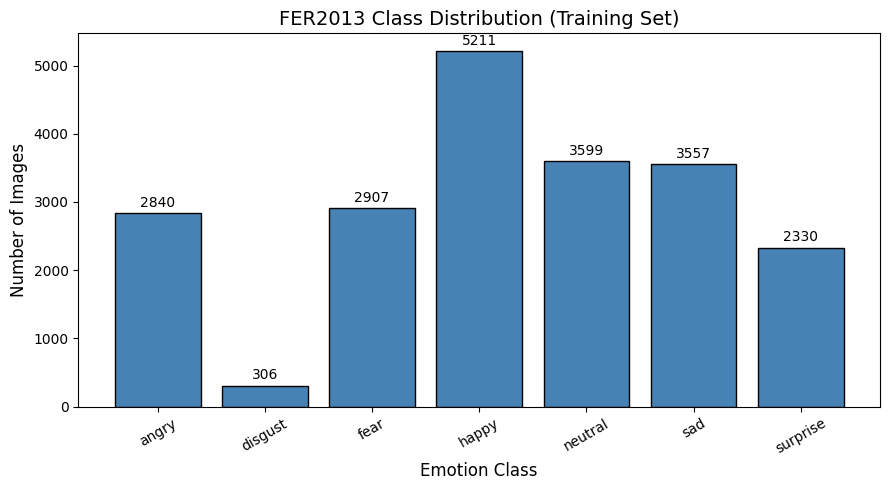


Class distribution:
  angry     :  2840  (13.7%)
  disgust   :   306  (1.5%)
  fear      :  2907  (14.0%)
  happy     :  5211  (25.1%)
  neutral   :  3599  (17.3%)
  sad       :  3557  (17.1%)
  surprise  :  2330  (11.2%)
  TOTAL     : 20750


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count training samples per class
unique, counts = np.unique(y_train, return_counts=True)
class_names_ordered = label_encoder.classes_

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    class_names_ordered,
    counts,
    color='steelblue',
    edgecolor='black'
)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        str(count),
        ha='center', va='bottom', fontsize=10
    )

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('FER2013 Class Distribution (Training Set)', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Print the numbers
print('\nClass distribution:')
total = sum(counts)
for name, count in zip(class_names_ordered, counts):
    pct = 100 * count / total
    print(f'  {name:10s}: {count:5d}  ({pct:.1f}%)')
print(f'  {"TOTAL":10s}: {total:5d}')

In [ ]:
from keras.models import load_model

model = load_model('model.keras')
print("Model loaded successfully")

# Verify it works
test_loss, test_acc = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Model loaded successfully
Test accuracy: 0.6243


In [ ]:
# Save the model with .keras extension
model.save("modelv1.keras")

In [ ]:
# Saving the model with .h5 extension
model.save('modelv1.h5')

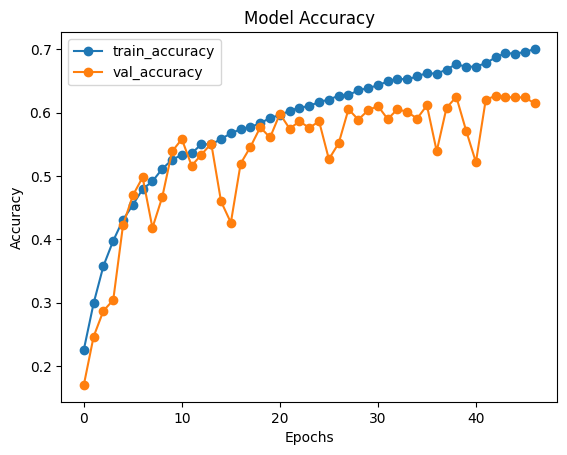

In [ ]:
# Plotting model performance
plt.plot(history.history['accuracy'], label='train_accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='val_accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
#Test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f'Test loss:     {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss:     1.0542
Test accuracy: 0.6243


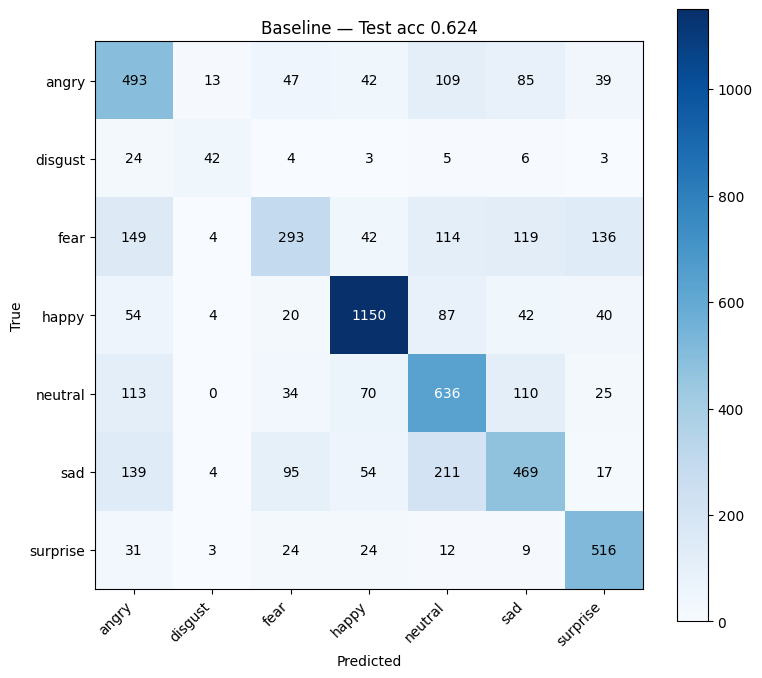

[[ 493   13   47   42  109   85   39]
 [  24   42    4    3    5    6    3]
 [ 149    4  293   42  114  119  136]
 [  54    4   20 1150   87   42   40]
 [ 113    0   34   70  636  110   25]
 [ 139    4   95   54  211  469   17]
 [  31    3   24   24   12    9  516]]


In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Baseline — Test acc {test_accuracy:.3f}')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=text_color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

print(cm)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions from baseline model
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = y_test  # already integer-encoded
class_names = label_encoder.classes_

# Per-class precision, recall, F1
print('BASELINE — Per-class metrics:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0, digits=3))

BASELINE — Per-class metrics:
              precision    recall  f1-score   support

       angry      0.492     0.595     0.539       828
     disgust      0.600     0.483     0.535        87
        fear      0.567     0.342     0.426       857
       happy      0.830     0.823     0.827      1397
     neutral      0.542     0.644     0.588       988
         sad      0.558     0.474     0.513       989
    surprise      0.665     0.834     0.740       619

    accuracy                          0.624      5765
   macro avg      0.608     0.599     0.595      5765
weighted avg      0.625     0.624     0.617      5765



In [ ]:
for layer in reversed(model.layers):
    if 'conv' in layer.name:
        last_conv_layer_name = layer.name
        break
print(f"Using last conv layer: {last_conv_layer_name}")

Using last conv layer: conv2d_7


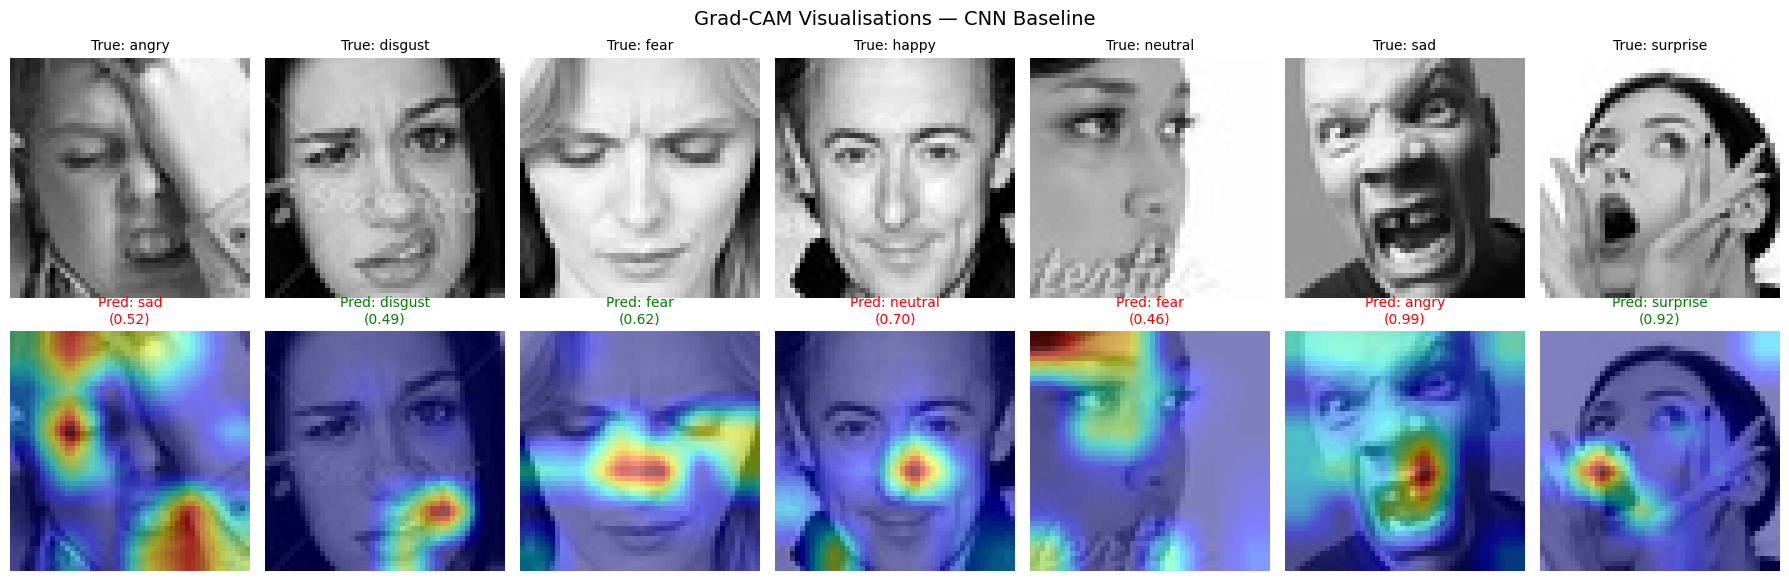

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Build a fresh functional model that exposes both conv outputs and predictions
    inputs = tf.keras.Input(shape=img_array.shape[1:])
    x = inputs
    conv_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x
    grad_model = tf.keras.Model(inputs=inputs, outputs=[conv_output, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


# Pick one sample per emotion
samples_per_class = {}
for class_idx, class_name in enumerate(class_names):
    indices = np.where(y_test == class_idx)[0]
    if len(indices) > 0:
        samples_per_class[class_name] = X_test[indices[0]]

# Generate Grad-CAM for each emotion
fig, axes = plt.subplots(2, 7, figsize=(18, 6))

for col, (class_name, img) in enumerate(samples_per_class.items()):
    img_batch = np.expand_dims(img, axis=0).astype('float32')
    preds = model.predict(img_batch, verbose=0)
    predicted_class = class_names[np.argmax(preds[0])]
    confidence = np.max(preds[0])

    heatmap = make_gradcam_heatmap(img_batch, model, last_conv_layer_name)
    heatmap_resized = cv2.resize(heatmap, (48, 48))

    axes[0, col].imshow(img.squeeze(), cmap='gray')
    axes[0, col].set_title(f'True: {class_name}', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(img.squeeze(), cmap='gray')
    axes[1, col].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    color = 'green' if predicted_class == class_name else 'red'
    axes[1, col].set_title(f'Pred: {predicted_class}\n({confidence:.2f})',
                            fontsize=10, color=color)
    axes[1, col].axis('off')

plt.suptitle('Grad-CAM Visualisations — CNN Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===== EXPERIMENT 1: 10 EPOCHS =====

# Build a fresh model (different name so we don't overwrite)
model_10ep = build_model()

# Train with only 10 epochs (using augmentation, same as baseline)
history_10ep = model_10ep.fit(
    data_gen.flow(X_train, y_train_categorical, batch_size=128),
    validation_data=(X_val, y_val_categorical),
    epochs=10,
    verbose=1
)

# Evaluate on test set
test_loss_10ep, test_acc_10ep = model_10ep.evaluate(X_test, y_test_categorical, verbose=0)
print(f'\n10 EPOCHS — Test accuracy: {test_acc_10ep:.4f}')
print(f'10 EPOCHS — Train accuracy (final): {history_10ep.history["accuracy"][-1]:.4f}')
print(f'10 EPOCHS — Val accuracy (final): {history_10ep.history["val_accuracy"][-1]:.4f}')

In [ ]:
# ===== EXPERIMENT 2: 100 EPOCHS =====

# Build a fresh model
model_100ep = build_model()

# Train for 100 epochs (using augmentation, same as baseline)
history_100ep = model_100ep.fit(
    data_gen.flow(X_train, y_train_categorical, batch_size=128),
    validation_data=(X_val, y_val_categorical),
    epochs=100,
    verbose=1
)

# Evaluate
test_loss_100ep, test_acc_100ep = model_100ep.evaluate(X_test, y_test_categorical, verbose=0)
print(f'\n100 EPOCHS — Test accuracy: {test_acc_100ep:.4f}')
print(f'100 EPOCHS — Train accuracy (final): {history_100ep.history["accuracy"][-1]:.4f}')
print(f'100 EPOCHS — Val accuracy (final): {history_100ep.history["val_accuracy"][-1]:.4f}')